# Analyse exploratoire des données relatives aux hotels.

In [1]:
########################
# EDA pour estimer les pondérations des critères de notation des hôtels
########################

Définition des critères de sélection des hôtels pour l'analyse du top 20 des hotels en fonction des paramètres météo et des avis clients :

- Critères météorologiques : cf ==> top_5_villes.ipynb
  - Température ressentie
  - Précipitations à 1h
  - Rafales de vent
  - Vitesse du vent
  - couverture nuageuse

- Critères des avis clients :
  - Note moyenne
  - Nombre d'avis
  - Distance par rapport au centre-ville

In [2]:
# Import des librairies pour l'EDA de Kayak
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [3]:
df = pd.read_csv("/Users/nicolasbour/Desktop/Projets_IA /Projets_certif/02_kayak/data/final_data_cleaned.csv")

In [4]:
df_eda = df.copy()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 875 entries, 0 to 874
Data columns (total 32 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   city                   875 non-null    object 
 1   lat                    875 non-null    float64
 2   lon                    875 non-null    float64
 3   visibility             875 non-null    int64  
 4   dt                     875 non-null    int64  
 5   main.temp              875 non-null    float64
 6   main.feels_like        875 non-null    float64
 7   main.temp_min          875 non-null    float64
 8   main.temp_max          875 non-null    float64
 9   main.pressure          875 non-null    int64  
 10  main.humidity          875 non-null    int64  
 11  main.sea_level         875 non-null    int64  
 12  main.grnd_level        875 non-null    int64  
 13  wind.speed             875 non-null    float64
 14  wind.deg               875 non-null    int64  
 15  wind.g

In [6]:
df_eda = df_eda[["city", "lat", "lon", "hotel_city", "latitude", "longitude", "hotel_name", "rate", "experience","price"]]

In [7]:
## Conversion des colonnes hotels features en format numérique
# Prix : "€ 1 140" -> 1140
df_eda["price_num"] = pd.to_numeric(
    df_eda["price"]
    .astype(str)
    .str.replace("€", "", regex=False)
    .str.replace(" ", "", regex=False),
    errors="coerce"
)

# Note : "8,7" -> 8.7
df_eda["rate_num"] = pd.to_numeric(
    df_eda["rate"]
    .astype(str)
    .str.replace(",", ".", regex=False),
    errors="coerce"
)

# Nombre d'avis : "2 889" -> 2889
df_eda["nb_reviews"] = pd.to_numeric(
    df_eda["experience"]
    .astype(str)
    .str.replace(" ", "", regex=False),
    errors="coerce"
)

In [8]:
def haversine(lat1, lon1, lat2, lon2):
    """
    Calcule la distance en kilomètres entre deux points GPS à partir de la formule de Haversine : 
    """
    
    R = 6371  # rayon moyen de la Terre en km
    
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = (
        np.sin(dlat / 2)**2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2)**2
    )
    
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    
    return R * c

In [9]:
df_eda["distance_center_km"] = haversine(
    df_eda["lat"],
    df_eda["lon"],
    df_eda["latitude"],
    df_eda["longitude"]
)

In [10]:
df_eda = df_eda.drop(["rate", "experience", "price"], axis=1)

In [11]:
df_eda.head()

,city,lat,lon,hotel_city,latitude,longitude,hotel_name,price_num,rate_num,nb_reviews,distance_center_km
0,mont saint michel,48.635954,-1.51146,Beauvoir,48.596052,-1.500324,La Villa du Manoir,521,9.8,6.0,4.511798
1,mont saint michel,48.635954,-1.51146,Huisnes-sur-Mer,48.621474,-1.447158,Escale du Mont,364,7.5,2.0,4.992520
2,mont saint michel,48.635954,-1.51146,Huisnes-sur-Mer,48.619514,-1.459112,Horizon du Mont 15 personnes,1140,9.7,10.0,4.259502
3,mont saint michel,48.635954,-1.51146,Beauvoir,48.594490,-1.511429,Ermitage,1954,8.7,152.0,4.610598
4,mont saint michel,48.635954,-1.51146,Beauvoir,48.597734,-1.511773,Le Petit Gîte du Mont,440,8.9,55.0,4.249943


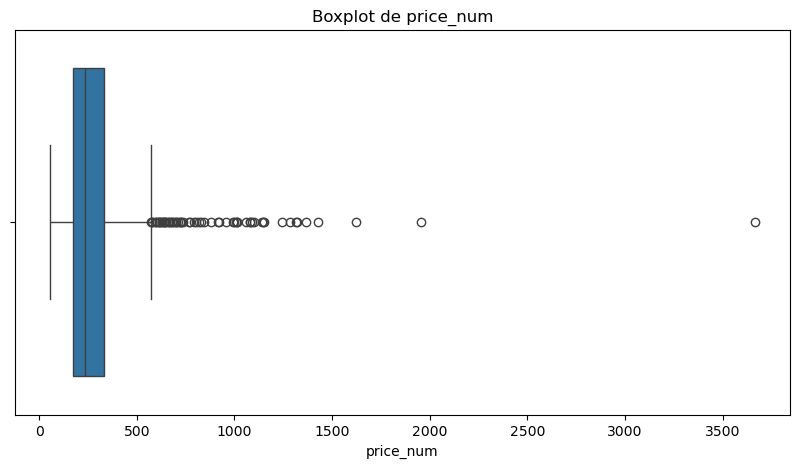

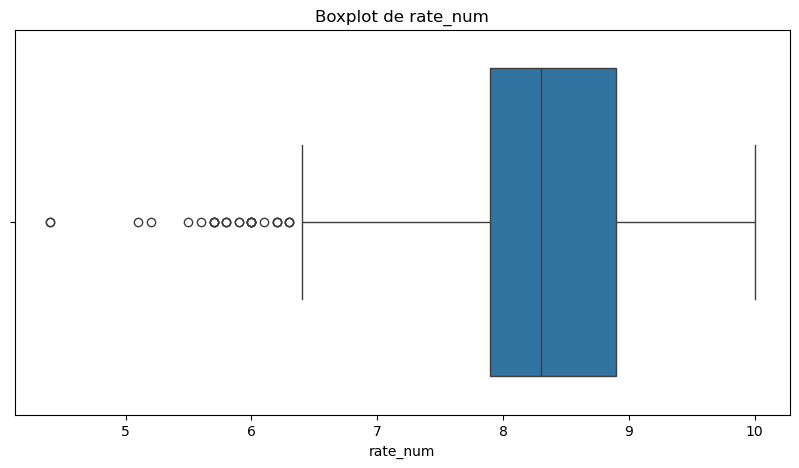

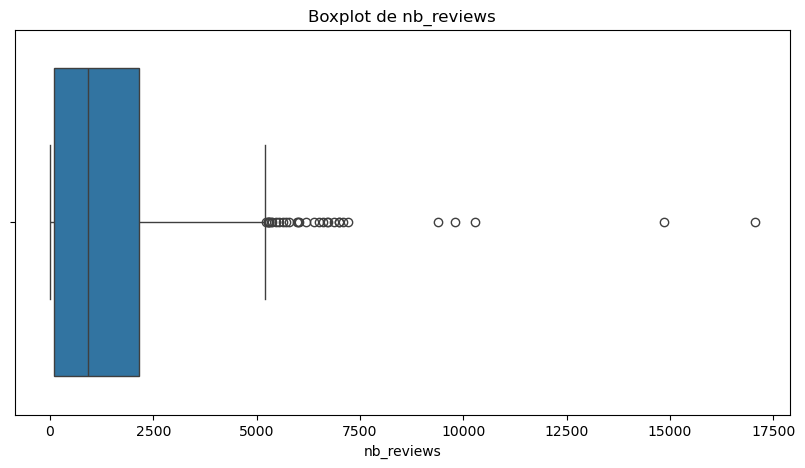

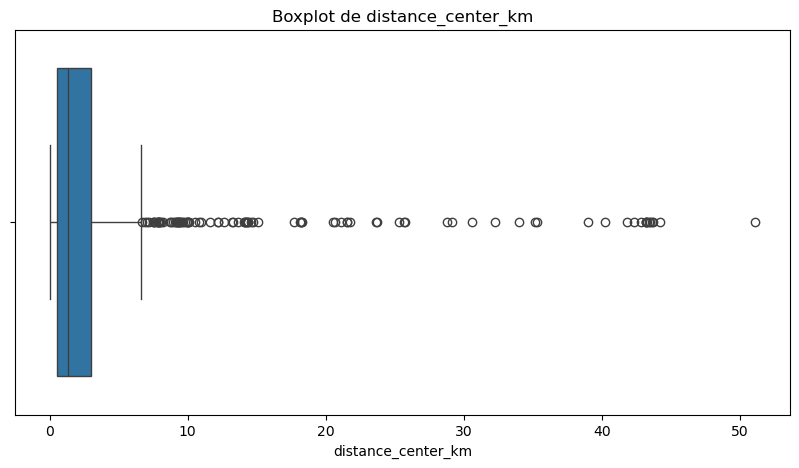

In [12]:
# Affichage et recherche des outliers pour les features numériques
numeric_features = ["price_num", "rate_num", "nb_reviews", "distance_center_km"]

for feature in numeric_features:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=df_eda[feature])
    plt.title(f"Boxplot de {feature}")
    plt.show()

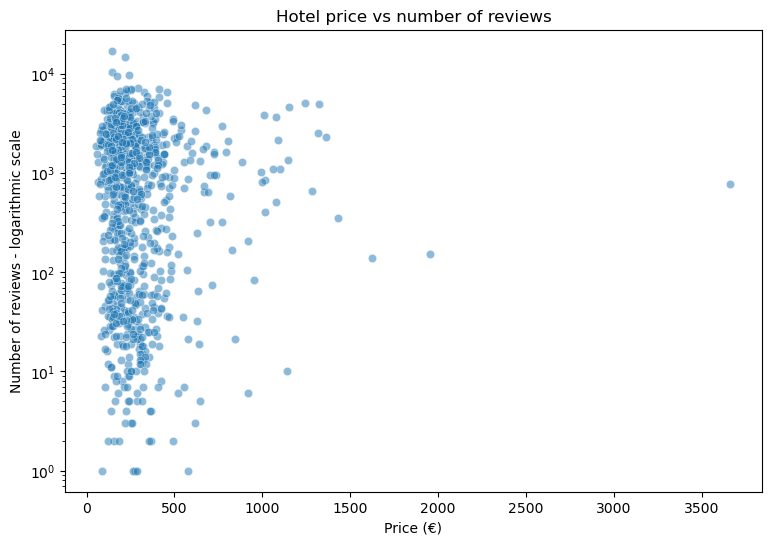

In [13]:
# Visualisation logarithmique du nombre d'avis en fonction du prix de l'hôtel afin 
# de mieux visualiser les hôtels avec un nombre d'avis très élevé (outliers)

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_eda,
    x="price_num",
    y="nb_reviews",
    alpha=0.5
)

plt.yscale("log")

plt.xlabel("Price (€)")
plt.ylabel("Number of reviews - logarithmic scale")
plt.title("Hotel price vs number of reviews")

plt.show()

Les features présentes des outliers qui peuvent fausser l'analyse. Il est donc nécessaire de les identifier et de les traiter avant de procéder à l'analyse du top 20 des hôtels.

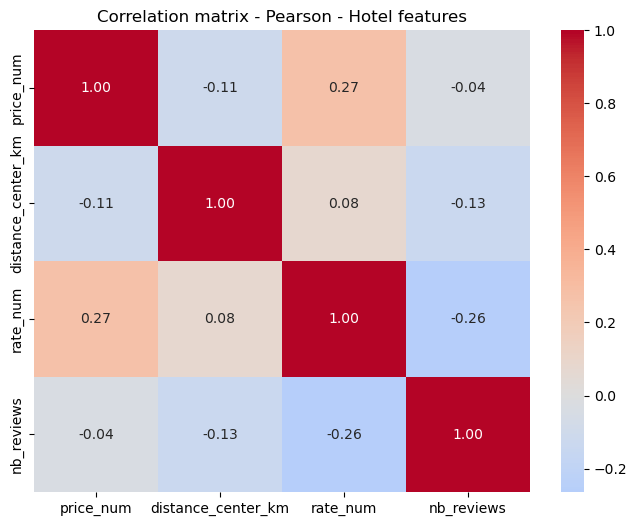

In [14]:
# Affichage de la matrice de corrélation (Méthode de calcul Pearson) afin de déterminer si des relations linéaires existent entre les features des hôtels.

corr_columns = [
    "price_num",
    "distance_center_km",
    "rate_num",
    "nb_reviews"
]

corr_matrix = df_eda[corr_columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    center=0
)

plt.title("Correlation matrix - Pearson - Hotel features")
plt.show()

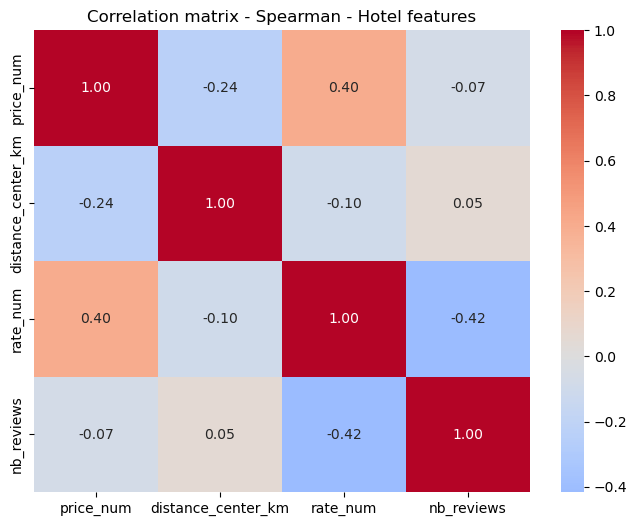

In [15]:
# Affichage de la matrice de corrélation (Méthode de calcul Spearman) afin de déterminer si des relations existent entre les features des hôtels de façon non linéaire.

corr_columns = [
    "price_num",
    "distance_center_km",
    "rate_num",
    "nb_reviews"
]

corr_matrix = df_eda[corr_columns].corr(method="spearman")

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    center=0
)

plt.title("Correlation matrix - Spearman - Hotel features")
plt.show()

In [16]:
variables = [
    "price_num",
    "distance_center_km",
    "rate_num",
    "nb_reviews"
]

pearson_corr = df_eda[variables].corr(method="pearson")
spearman_corr = df_eda[variables].corr(method="spearman")

print("Pearson correlation")
display(pearson_corr)

print("\nSpearman correlation")
display(spearman_corr)

Pearson correlation


,price_num,distance_center_km,rate_num,nb_reviews
price_num,1.000000,-0.109832,0.270762,-0.035422
distance_center_km,-0.109832,1.000000,0.079751,-0.134507
rate_num,0.270762,0.079751,1.000000,-0.264475
nb_reviews,-0.035422,-0.134507,-0.264475,1.000000



Spearman correlation


,price_num,distance_center_km,rate_num,nb_reviews
price_num,1.000000,-0.239196,0.402265,-0.073589
distance_center_km,-0.239196,1.000000,-0.100783,0.052465
rate_num,0.402265,-0.100783,1.000000,-0.416475
nb_reviews,-0.073589,0.052465,-0.416475,1.000000


# Matrice de Pearson. 

Le nombre d'avis ne montre pas de corrélation significative avec les autres features. Il pourra donc servir uniquement à donner du crédit à la note moyenne de l'hotel. 

la note de l'hotel semble légèrement corrélée avec le prix de l'hotel. 

La distance par rapport au centre-ville ne semble pas non plus corrélé avec les autres features. 

==> La matrice de Pearson montre peu de correlation linéaire entre les features.


# Matrice de Spearman.

Le nombre d'avis montre une tendance à avoir une corrélation négative avec la note de l'hotel. 

La note de l'hotel semble également positivement corrélée avec le prix de l'hotel.

La distance par rapport au centr-ville semble avoir une légère corrélation négative avec la note de l'hotel.

==> La matrice de Spearman montre des corrélations non linéaires entre les features.

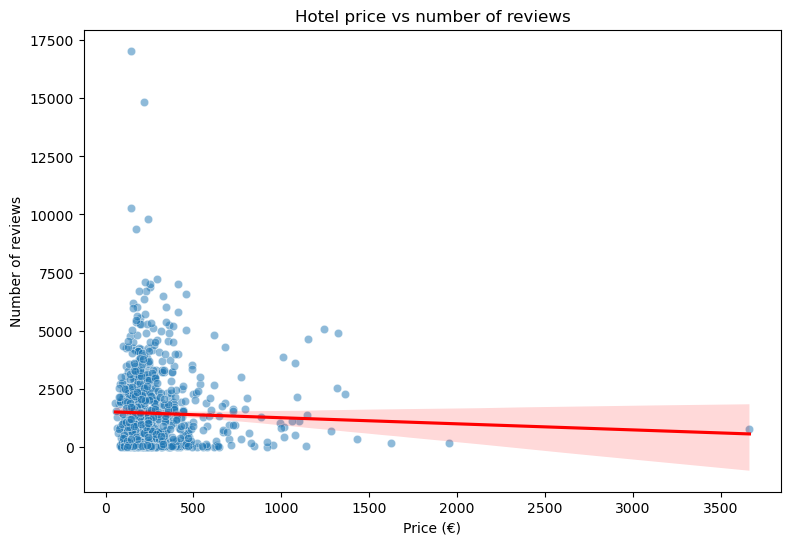

In [17]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_eda,
    x="price_num",
    y="nb_reviews",
    alpha=0.5
)

sns.regplot(
    data=df_eda,
    x="price_num",
    y="nb_reviews",
    scatter=False,
    color="red"
)

plt.xlabel("Price (€)")
plt.ylabel("Number of reviews")
plt.title("Hotel price vs number of reviews")

plt.show()

Analyse : A voir après nettoyage des outliers

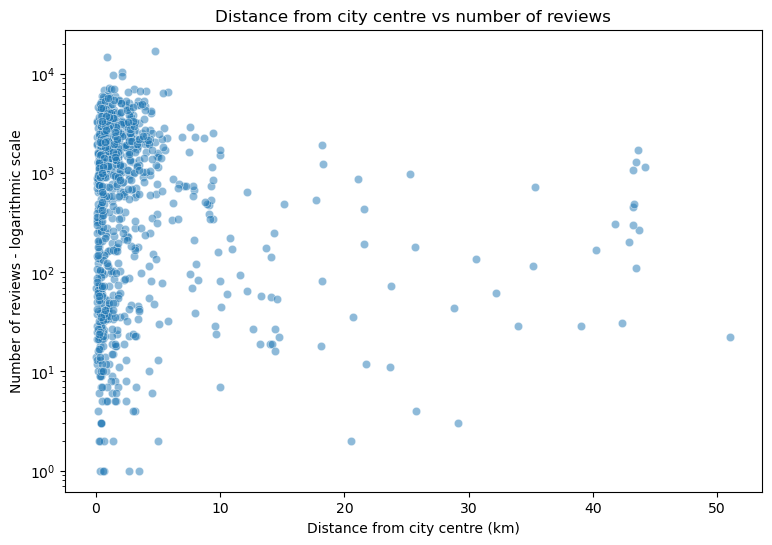

In [18]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_eda,
    x="distance_center_km",
    y="nb_reviews",
    alpha=0.5
)

plt.yscale("log")

plt.xlabel("Distance from city centre (km)")
plt.ylabel("Number of reviews - logarithmic scale")
plt.title("Distance from city centre vs number of reviews")

plt.show()

Le nombre d'avis et d'hotels sont assez proches des centres villes. Le nombre d'avis semble être plus élevé pour les hotels situés à proximité du centre-ville. Cependant, aucune corrélation n'a pu être démontrée, d'autres features sont à prendre en compte mais on peut en déduire que les hôtels situés à proximité du centre-ville sont plus représentés.

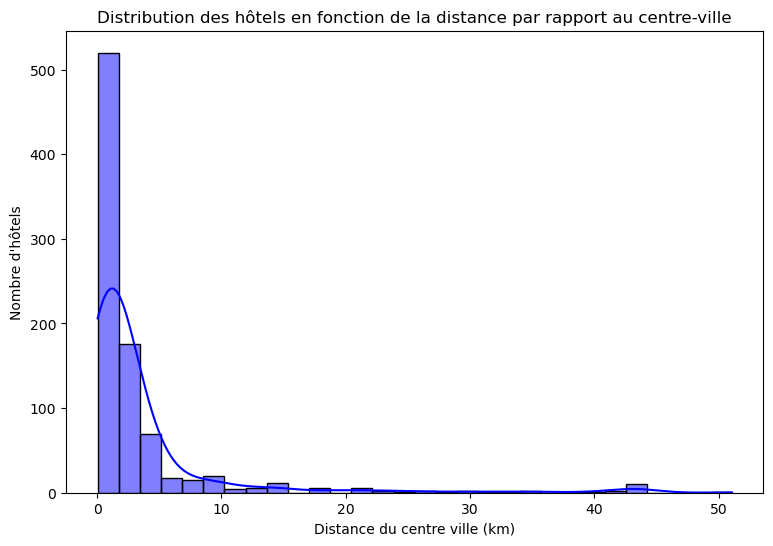

In [19]:
# Distribution des hotels en fonction de leur distance par rapport au centre-ville
plt.figure(figsize=(9, 6))

sns.histplot(
    data=df_eda,
    x="distance_center_km",
    bins=30,
    kde=True,
    color="blue"
)
plt.xlabel("Distance du centre ville (km)")
plt.ylabel("Nombre d'hôtels")
plt.title("Distribution des hôtels en fonction de la distance par rapport au centre-ville")
plt.show()

Ce graphique confirme une sur-représentation des hotels situés à proximité et explique le phénomène de nombre d'avis élevé pour les hotels situés à proximité du centre-ville. 

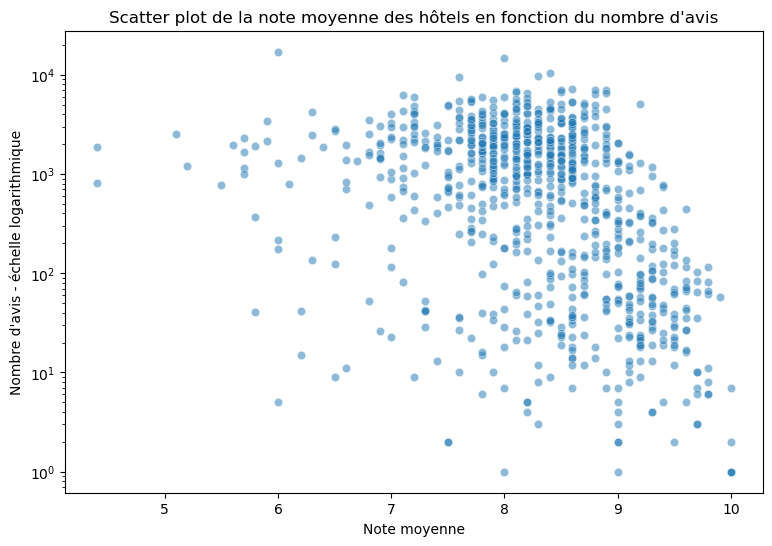

In [20]:
# Visualisation logarithmique du nombre d'avis en fonction de la note de l'hôtel afin
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_eda,
    x="rate_num",
    y="nb_reviews",
    alpha=0.5
)

plt.yscale("log")

plt.xlabel("Note moyenne")
plt.ylabel("Nombre d'avis - échelle logarithmique")
plt.title("Scatter plot de la note moyenne des hôtels en fonction du nombre d'avis")

plt.show()

In [21]:
# Distribution du nombre moyen d'avis en fonction de la note moyenne
reviews_by_rate = (
    df_eda[["rate_num", "nb_reviews"]]
    .dropna(subset=["rate_num", "nb_reviews"])
    .groupby("rate_num", as_index=False)
    .agg(
        mean_reviews=("nb_reviews", "mean"),
        median_reviews=("nb_reviews", "median"),
        number_of_hotels=("nb_reviews", "size"),
        sum_reviews=("nb_reviews", "sum")
    )
    .sort_values("rate_num")
)

fig_mean = px.bar(
    reviews_by_rate,
    x="rate_num",
    y="mean_reviews",
    text="mean_reviews",
    hover_data={
        "rate_num": ":.1f",
        "mean_reviews": ":,.0f",
        "median_reviews": ":,.0f",
        "number_of_hotels": True
    },
    labels={
        "rate_num": "Note moyenne",
        "mean_reviews": "Nombre moyen d'avis",
        "median_reviews": "Nombre médian d'avis",
        "number_of_hotels": "Nombre d'hôtels"
    },
    title="Nombre moyen d'avis par hôtel selon la note",
    template="plotly_white"
)

fig_mean.update_traces(
    texttemplate="%{text:,.0f}",
    textposition="outside",
    marker_color="#2E86AB"
)

fig_mean.update_layout(
    xaxis=dict(
        title="Note moyenne de l'hôtel",
        dtick=0.5
    ),
    yaxis=dict(
        title="Nombre moyen d'avis par hôtel",
        separatethousands=True
    ),
    height=600,
    showlegend=False
)

fig_mean.show()

In [22]:
# Distribution du nombre d'hôtels en fonction de la note moyenne
fig_total = px.bar(
    reviews_by_rate,
    x="rate_num",
    y="number_of_hotels",
    text="number_of_hotels",
    hover_data={
        "rate_num": ":.1f",
        "number_of_hotels": True,
        "mean_reviews": ":,.0f",
        "median_reviews": ":,.0f"
    },
    labels={
        "rate_num": "Note moyenne",
        "number_of_hotels": "Nombre d'hôtels",
        "mean_reviews": "Nombre moyen d'avis",
        "median_reviews": "Nombre médian d'avis"
    },
    title="Nombre d'hôtels disponibles selon la note",
    template="plotly_white"
)

fig_total.update_traces(
    texttemplate="%{text:,.0f}",
    textposition="outside",
    marker_color="#7A5195"
)

fig_total.update_layout(
    xaxis=dict(
        title="Note moyenne de l'hôtel",
        dtick=0.5
    ),
    yaxis=dict(
        title="Nombre d'hôtels",
        separatethousands=True
    ),
    height=600,
    showlegend=False
)

fig_total.show()

In [23]:
fig = px.bar(
    reviews_by_rate,
    x="rate_num",
    y="sum_reviews",
    text="sum_reviews",
    hover_data={
        "rate_num": ":.1f",
        "number_of_hotels": ":,.0f",
        "sum_reviews": ":,.0f",
        "mean_reviews": ":,.0f",
        "median_reviews": ":,.0f"
    },
    labels={
        "rate_num": "Note moyenne",
        "sum_reviews": "Nombre total d'avis",
        "number_of_hotels": "Nombre d'hôtels",
        "mean_reviews": "Nombre moyen d'avis par hôtel",
        "median_reviews": "Nombre médian d'avis"
    },
    title="Nombre total d'avis par note moyenne",
    template="plotly_white"
)

fig.update_traces(
    texttemplate="%{text:,.0f}",
    textposition="outside",
    marker_color="#2E86AB"
)

fig.update_layout(
    xaxis=dict(
        title="Note moyenne",
        dtick=0.5
    ),
    yaxis=dict(
        title="Nombre total d'avis",
        separatethousands=True
    ),
    height=600,
    showlegend=False
)

fig.show()

In [24]:
from plotly.subplots import make_subplots

# Graphique avec deux axes Y
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Barres : nombre total d'avis
fig.add_trace(
    go.Bar(
        x=reviews_by_rate["rate_num"],
        y=reviews_by_rate["sum_reviews"],
        name="Nombre total d'avis",
        marker_color="#2E86AB",
        opacity=0.85,
        text=reviews_by_rate["sum_reviews"],
        texttemplate="%{text:,.0f}",
        textposition="outside",
        hovertemplate=(
            "Note : %{x:.1f}<br>"
            "Nombre total d'avis : %{y:,.0f}<extra></extra>"
        )
    ),
    secondary_y=False
)

# Ligne : nombre d'hôtels
fig.add_trace(
    go.Scatter(
        x=reviews_by_rate["rate_num"],
        y=reviews_by_rate["number_of_hotels"],
        name="Nombre d'hôtels",
        mode="lines+markers+text",
        text=reviews_by_rate["number_of_hotels"],
        texttemplate="%{text:,.0f}",
        textposition="top center",
        line=dict(
            color="#E74C3C",
            width=3
        ),
        marker=dict(
            size=9,
            color="#E74C3C"
        ),
        hovertemplate=(
            "Note : %{x:.1f}<br>"
            "Nombre d'hôtels : %{y:,.0f}<extra></extra>"
        )
    ),
    secondary_y=True
)

# Axe X
fig.update_xaxes(
    title_text="Note moyenne de l'hôtel",
    dtick=0.5
)

# Axe Y gauche : nombre total d'avis
fig.update_yaxes(
    title_text="Nombre total d'avis",
    separatethousands=True,
    secondary_y=False
)

# Axe Y droit : nombre d'hôtels
fig.update_yaxes(
    title_text="Nombre d'hôtels",
    separatethousands=True,
    secondary_y=True
)

fig.update_layout(
    title="Nombre total d'avis et nombre d'hôtels selon la note",
    template="plotly_white",
    height=650,
    bargap=0.25,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    ),
    margin=dict(t=100, r=100)
)

fig.show()

La répartition des hôtels et des avis par rapport à la note de l'hotel montre que certains hotels moins bien notés sont peu nombreux et montrent un nombre d'avis élevé, ce qui fausse l'analyse.

De 4.5 à 8.7 le nombre d'avis suit la même tendance que le nombre d'hotels mais à partir de 8.7 la tendance semble ralentir légèrement et le nombre d'avis diminue fortement alors que le nombre d'hotels diminue plus progressivement. 

# Exploration des données par un modele de clustering.

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AffinityPropagation
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.decomposition import PCA

In [26]:
# Préparation des données pour le clustering
features = ["price_num", "distance_center_km", "rate_num", "nb_reviews"]
cluster_data = df_eda[features].dropna()

In [27]:
# Utilisation de la transformation logarithmique pour réduire l'impact des 
# outliers sur les variables numériques notamment sur des variables comme le prix et le nombre d'avis. 
# log1p(x) = log(1 + x), adaptée aux variables positives
for column in ["price_num", "nb_reviews", "distance_center_km"]:
    cluster_data[column] = np.log1p(cluster_data[column])

In [28]:
X = cluster_data

In [29]:
# Transformation des données pour le clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [30]:
print(f"Nombre d'hôtels utilisés : {len(cluster_data)}")
print(f"Nombre de variables utilisées : {X_scaled.shape[1]}")

Nombre d'hôtels utilisés : 865
Nombre de variables utilisées : 4


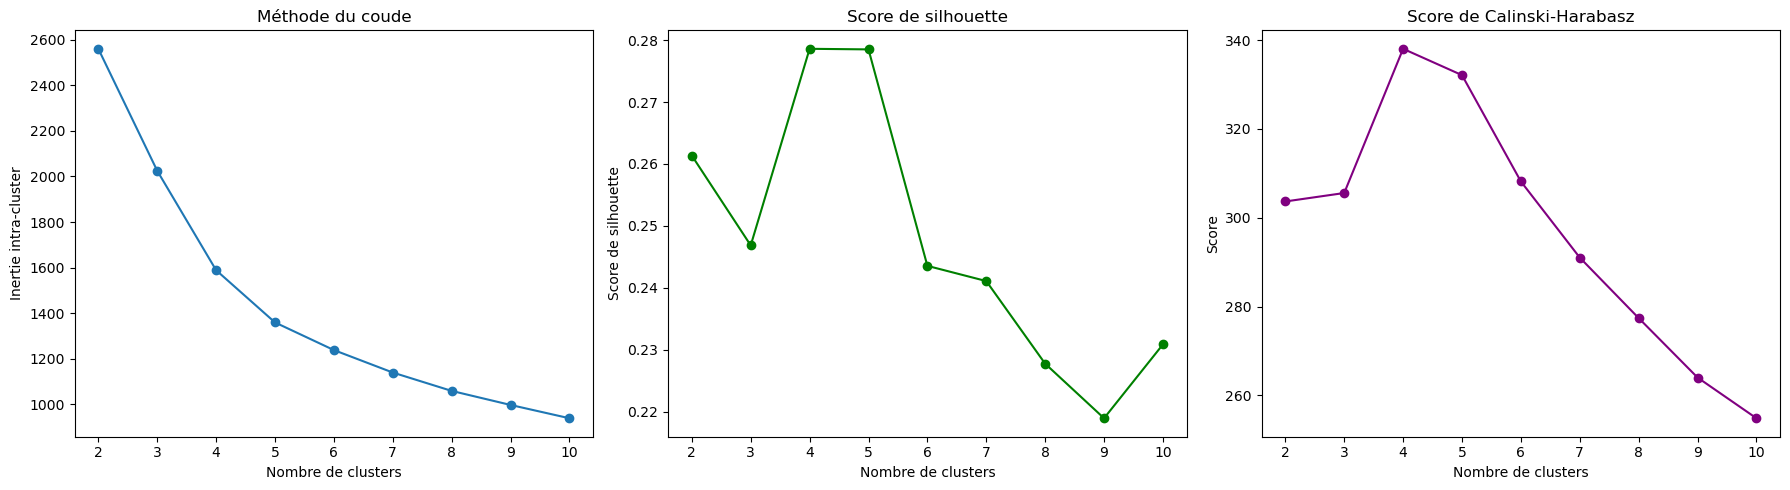

Nombre de clusters recommandé selon la silhouette : 4
Meilleur score de silhouette : 0.279


In [31]:
# Détermination du nombre optimal de clusters avec la méthode du coude, 
# le score de silhouette et le score de Calinski-Harabasz.
k_values = range(2, 11)

inertias = []
silhouette_scores = []
calinski_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )
    calinski_scores.append(
        calinski_harabasz_score(X_scaled, labels)
    )

# Affichage des indicateurs
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Méthode du coude
axes[0].plot(k_values, inertias, marker="o")
axes[0].set_title("Méthode du coude")
axes[0].set_xlabel("Nombre de clusters")
axes[0].set_ylabel("Inertie intra-cluster")

# Score de silhouette
axes[1].plot(k_values, silhouette_scores, marker="o", color="green")
axes[1].set_title("Score de silhouette")
axes[1].set_xlabel("Nombre de clusters")
axes[1].set_ylabel("Score de silhouette")

# Score de Calinski-Harabasz
axes[2].plot(k_values, calinski_scores, marker="o", color="purple")
axes[2].set_title("Score de Calinski-Harabasz")
axes[2].set_xlabel("Nombre de clusters")
axes[2].set_ylabel("Score")

plt.tight_layout()
plt.show()

best_k = k_values[np.argmax(silhouette_scores)]

print(f"Nombre de clusters recommandé selon la silhouette : {best_k}")
print(
    f"Meilleur score de silhouette : "
    f"{max(silhouette_scores):.3f}"
)

In [32]:
# Entraînement du modèle K-Means avec le nombre optimal de clusters
kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

cluster_data["kmeans_cluster"] = kmeans_final.fit_predict(X_scaled)

print(
    "Score de silhouette K-Means :",
    silhouette_score(
        X_scaled,
        cluster_data["kmeans_cluster"]
    )
)

# Nombre d'hôtels dans chaque cluster
print(
    cluster_data["kmeans_cluster"]
    .value_counts()
    .sort_index()
)

Score de silhouette K-Means : 0.2785879530641411
kmeans_cluster
0    288
1    285
2    202
3     90
Name: count, dtype: int64


In [33]:
# Visualisation des clusters avec PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=cluster_data.index
)

pca_df["cluster"] = cluster_data["kmeans_cluster"].astype(str)

fig = px.scatter(
    pca_df,
    x="PC1",
    y="PC2",
    color="cluster",
    title="Clusters K-Means représentés par une ACP",
    labels={
        "cluster": "Cluster K-Means"
    },
    template="plotly_white",
    opacity=0.7
)

fig.update_layout(height=600)
fig.show()

print(
    f"Variance expliquée par PC1 et PC2 : "
    f"{pca.explained_variance_ratio_.sum():.1%}"
)

Variance expliquée par PC1 et PC2 : 68.9%


In [34]:
# Ajout du cluster au dataframe original
cluster_results = df_eda.loc[cluster_data.index, features].copy()
cluster_results["kmeans_cluster"] = cluster_data["kmeans_cluster"]

# Statistiques descriptives par cluster
# cluster_summary = (
#     cluster_results
#     .groupby("kmeans_cluster")
#     .agg(
#         number_of_hotels=("rate_num", "size"),
#         mean_price=("price_num", "mean"),
#         median_price=("price_num", "median"),
#         mean_rate=("rate_num", "mean"),
#         mean_reviews=("nb_reviews", "mean"),
#         median_reviews=("nb_reviews", "median"),
#         mean_distance=("distance_center_km", "mean"),
#         median_distance=("distance_center_km", "median")
#     )
#     .round(2)
# )
cluster_summary = (
    cluster_results
    .groupby("kmeans_cluster")
    .agg(
        number_of_hotels=("hotel_name", "size")
        if "hotel_name" in cluster_results.columns
        else ("rate_num", "size"),
        mean_price=("price_num", "mean"),
        median_price=("price_num", "median"),
        mean_rate=("rate_num", "mean"),
        mean_reviews=("nb_reviews", "mean"),
        median_reviews=("nb_reviews", "median"),
        mean_distance=("distance_center_km", "mean"),
        median_distance=("distance_center_km", "median")
    )
)

# Pourcentage d'hôtels dans chaque cluster
cluster_summary["share_of_hotels_%"] = (
    cluster_summary["number_of_hotels"]
    / cluster_summary["number_of_hotels"].sum()
    * 100
)

# Réorganisation des colonnes
cluster_summary = cluster_summary[
    [
        "number_of_hotels",
        "share_of_hotels_%",
        "mean_price",
        "median_price",
        "mean_rate",
        "mean_reviews",
        "median_reviews",
        "mean_distance",
        "median_distance"
    ]
].round(2)

display(cluster_summary)

,number_of_hotels,share_of_hotels_%,mean_price,median_price,mean_rate,mean_reviews,median_reviews,mean_distance,median_distance
kmeans_cluster,,,,,,,,,
0,288,33.29,438.33,343.0,8.47,2039.28,1576.5,1.33,0.93
1,285,32.95,169.45,168.0,7.50,2132.47,1862.0,2.28,1.75
2,202,23.35,292.19,261.0,8.90,59.25,35.0,1.11,0.66
3,90,10.40,221.19,198.5,8.78,353.50,139.0,19.28,14.16


In [37]:
comparison_columns = [
    "price_num",
    "rate_num",
    "nb_reviews",
    "distance_center_km"
]

# Moyennes globales
global_means = (
    cluster_results[comparison_columns]
    .mean()
    .rename("global_mean")
)

# Moyennes par cluster
cluster_means = (
    cluster_results
    .groupby("kmeans_cluster")[comparison_columns]
    .mean()
)

# Écart en pourcentage par rapport à la moyenne globale
cluster_comparison = (
    cluster_means
    .subtract(global_means)
    .divide(global_means)
    .multiply(100)
    .round(1)
)

cluster_comparison.columns = [
    "prix_vs_global_%",
    "note_vs_global_%",
    "avis_vs_global_%",
    "distance_vs_global_%"
]

display(cluster_comparison)

,prix_vs_global_%,note_vs_global_%,avis_vs_global_%,distance_vs_global_%
kmeans_cluster,,,,
0,49.6,2.3,42.4,-61.5
1,-42.2,-9.5,48.9,-34.2
2,-0.3,7.5,-95.9,-67.8
3,-24.5,5.9,-75.3,457.3


In [35]:
affinity = AffinityPropagation(
    damping=0.9,
    random_state=42,
    max_iter=500,
    convergence_iter=30
)

affinity_labels = affinity.fit_predict(X_scaled)

number_of_affinity_clusters = len(
    np.unique(affinity_labels)
)

print(
    f"Nombre de clusters Affinity Propagation : "
    f"{number_of_affinity_clusters}"
)

if number_of_affinity_clusters > 1:
    affinity_silhouette = silhouette_score(
        X_scaled,
        affinity_labels
    )
    
    print(
        f"Score de silhouette Affinity Propagation : "
        f"{affinity_silhouette:.3f}"
    )
else:
    print(
        "Un seul cluster a été obtenu : "
        "le score de silhouette ne peut pas être calculé."
    )

Nombre de clusters Affinity Propagation : 43
Score de silhouette Affinity Propagation : 0.185


In [36]:
affinity_pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=cluster_data.index
)

affinity_pca_df["cluster"] = affinity_labels.astype(str)

fig = px.scatter(
    affinity_pca_df,
    x="PC1",
    y="PC2",
    color="cluster",
    title="Clusters Affinity Propagation représentés par une ACP",
    labels={
        "cluster": "Cluster Affinity Propagation"
    },
    template="plotly_white",
    opacity=0.7
)

fig.update_layout(height=600)
fig.show()